In [6]:
import time
import matplotlib.pyplot as plt
from moku.instruments import FrequencyResponseAnalyzer
import traceback

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

Buscando o Moku:Go na rede pelo IP: 192.168.73.1...
Conexão bem-sucedida! Configurando o instrumento...
Iniciando varredura...
Aguardando varredura... (Script em espera)
Extraindo matrizes de dados da RAM...


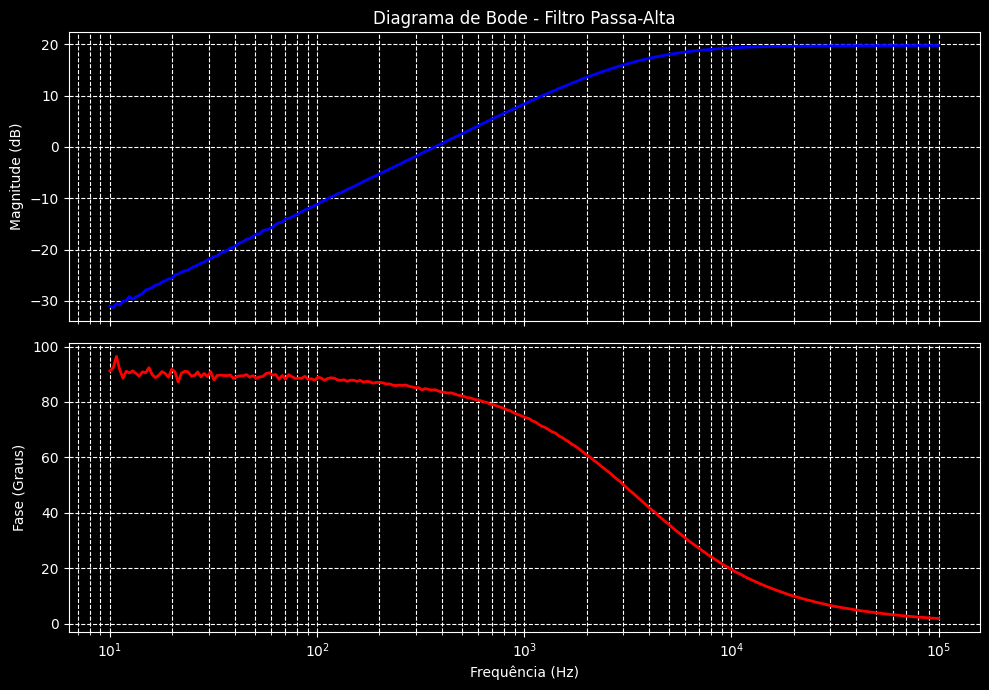

Conexão encerrada.


In [ ]:
MOKU_IP = '192.168.73.1' # IP do equipamento
FRA = None # Garante que a variável existe, mesmo se a conexão explodir
# FRA: Frequency Response Analyzer

try:
    print(f"Buscando o Moku:Go na rede pelo IP: {MOKU_IP}...")
    FRA = FrequencyResponseAnalyzer(MOKU_IP, force_connect=True) # force_connect=True garante controle mesmo com o app aberto
    print("Conexão bem-sucedida! Configurando o instrumento...")
    
    # 1. Configura a varredura
    FRA.set_sweep(
        start_frequency=10, stop_frequency=100e3, num_points=256,
        settling_cycles=2, averaging_cycles=2, strict=False
    )
    FRA.set_output(1, amplitude=1.0, offset=0.0)
    
    # 3. Inicia a varredura
    print("Iniciando varredura...")
    FRA.start_sweep()
    
    # 4. Espera terminar e extrai os dados em uma única operação
    print("Aguardando varredura... (Script em espera)")
    data = FRA.get_data(wait_complete=True)
    
    # # --- BLOCO DE DIAGNÓSTICO ---
    # print("\n--- MAPEAMENTO DO DICIONÁRIO DE DADOS ---")
    # print("Chaves primárias encontradas:", list(data.keys()))
    
    # for key in data.keys():
    #     if isinstance(data[key], dict):
    #         print(f"-> Sub-chaves dentro de '{key}':", list(data[key].keys()))
    #     elif isinstance(data[key], list) or isinstance(data[key], np.ndarray):
    #         print(f"-> A chave '{key}' é um array com {len(data[key])} elementos.")
    
    # 5. Extração e Tratamento dos Dados (Convertendo saída do Moku para Arrays do NumPy)
    print("Extraindo matrizes de dados da RAM...")
    freqs = np.array(data['ch1']['frequency'])

    # Usando as chaves atualizadas da API ('magnitude' e 'phase')
    mag_ch1 = np.array(data['ch1']['magnitude'])
    mag_ch2 = np.array(data['ch2']['magnitude'])
    phase_ch1 = np.array(data['ch1']['phase'])
    phase_ch2 = np.array(data['ch2']['phase'])
    
    # A atenuação real do filtro (CH2 - CH1) --> Magnitude (dB) = 20 * log10(|Vout/Vin|) = Mag_CH2(dB) - Mag_CH1(dB)
    transfer_magnitude = mag_ch2 - mag_ch1
    transfer_phase = np.rad2deg( np.unwrap( np.deg2rad( phase_ch2 - phase_ch1 ) ) ) # Unwrap da fase para evitar saltos de 360 graus

    # 6. Visualização Rápida
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    
    ax1.semilogx(freqs, transfer_magnitude, color='b', linewidth=2)
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_title('Diagrama de Bode - Filtro Passa-Alta')
    ax1.grid(True, which="both", ls="--")
    
    ax2.semilogx(freqs, transfer_phase, color='r', linewidth=2)
    ax2.set_xlabel('Frequência (Hz)')
    ax2.set_ylabel('Fase (Graus)')
    ax2.grid(True, which="both", ls="--")
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    traceback.print_exc()

finally: # MANDATÓRIO: Libera o instrumento para não travar o Moku:Go
    if FRA is not None: # Só tenta liberar se o instrumento realmente foi conectado
        FRA.relinquish_ownership()
        print("Conexão encerrada.")

Palpites Iniciais: fc = 3604.65 Hz, Ganho = 19.76 dB

--- RESULTADOS DA OTIMIZAÇÃO ---
Frequência de Corte Real (fc): 3591.67 Hz ± 6.55 Hz
Ganho na Banda de Passagem : 19.79 dB


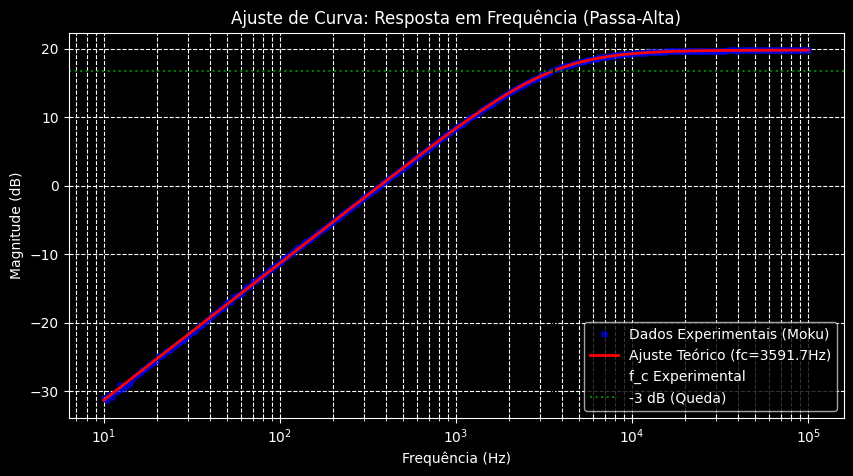

In [13]:
# 1. Colocando os dados no Pandas (organização e facilidade de manipulação)
df = pd.DataFrame({
    'Frequency': freqs,         # Array do Moku:Go
    'Magnitude_dB': transfer_magnitude,
    'Phase_deg': transfer_phase
})

# 2. Definindo o modelo matemático exato do Passa-Alta em dB
def high_pass_model(f, fc, k_db):
    """
    f: Frequência em Hz
    fc: Frequência de corte (-3dB) em Hz
    k_db: Ganho assimétrico na banda de passagem (idealmente 0 dB)
    """
    ratio_sq = (f / fc)**2
    # O 1e-12 evita avisos de log(0) caso o algoritmo tente testar frequências nulas
    return k_db + 10 * np.log10(ratio_sq / (1 + ratio_sq) + 1e-12)

# 3. O Ponto Cego: Palpites Iniciais (p0) Dinâmicos
# Nunca deixe o SciPy adivinhar do zero. Vamos extrair estimativas dos próprios dados.

# O ganho k_db na banda de passagem será aproximadamente o valor máximo medido
k_db_guess = df['Magnitude_dB'].max()

# A frequência de corte (fc) ocorre quando a magnitude cai ~3dB do máximo.
# Vamos encontrar o ponto de dado mais próximo de (k_db_guess - 3)
target_mag = k_db_guess - 3
idx_closest = (df['Magnitude_dB'] - target_mag).abs().argmin()
fc_guess = df['Frequency'].iloc[idx_closest]

print(f"Palpites Iniciais: fc = {fc_guess:.2f} Hz, Ganho = {k_db_guess:.2f} dB")

# 4. O Ajuste Fino (Curve Fit) com Limites (Bounds)
# A frequência de corte NÃO PODE ser negativa. O limite inferior de fc é 0.
try:
    popt, pcov = curve_fit(
        f=high_pass_model,
        xdata=df['Frequency'],
        ydata=df['Magnitude_dB'],
        p0=[fc_guess, k_db_guess],
        bounds=([0, -np.inf], [np.inf, np.inf]) # fc > 0, k_db livre
    )
    
    fc_opt, k_opt = popt
    
    # pcov contém a matriz de covariância. A diagonal é a variância dos parâmetros.
    # É assim que sabemos se o ajuste foi confiável ou um "chute solto".
    fc_error = np.sqrt(pcov[0, 0])
    
    print("\n--- RESULTADOS DA OTIMIZAÇÃO ---")
    print(f"Frequência de Corte Real (fc): {fc_opt:.2f} Hz ± {fc_error:.2f} Hz")
    print(f"Ganho na Banda de Passagem : {k_opt:.2f} dB")
    
    # 5. Plotando para verificar a sanidade do ajuste
    df['Fitted_Magnitude'] = high_pass_model(df['Frequency'], fc_opt, k_opt)
    
    plt.figure(figsize=(10, 5))
    plt.semilogx(df['Frequency'], df['Magnitude_dB'], 'bo', label='Dados Experimentais (Moku)', markersize=4, alpha=0.6)
    plt.semilogx(df['Frequency'], df['Fitted_Magnitude'], 'r-', label=f'Ajuste Teórico (fc={fc_opt:.1f}Hz)', linewidth=2)
    
    plt.axvline(fc_opt, color='k', linestyle='--', label='f_c Experimental')
    plt.axhline(k_opt - 3, color='g', linestyle=':', label='-3 dB (Queda)')
    
    plt.title('Ajuste de Curva: Resposta em Frequência (Passa-Alta)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

except RuntimeError:
    print("O SciPy não conseguiu convergir para uma solução. Verifique a qualidade dos seus dados ou o range da varredura.")